# Code Notebook for Data 275P Homework 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

import requests                                      # reading data
from io import StringIO
import re                                            # regular expressions

Matplotlib is building the font cache; this may take a moment.
/Users/franzclarin/Desktop/DATA-275P/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


<hr style="height: 3px;">

### Load the data

In [2]:
url = 'https://www.ics.uci.edu/~ihler/classes/data275P/data/data275P-hw1-gamma.txt'
nTrain = 15216

with requests.get(url) as link:
    datafile = StringIO(link.text)
    gamma_data = np.genfromtxt(datafile,delimiter=' ')
    nTrain = int( gamma_data.shape[0] * 0.8 )
    train, train_labels = gamma_data[:nTrain,:-1], gamma_data[:nTrain,-1]
    test, test_labels = gamma_data[nTrain:,:-1], gamma_data[nTrain:,-1]

# train: training matrix of 10 continuous observations from star showers.
# train_labels: column vector of {0,1} training labels where 0=hadron,1=gamma.
# test: test matrix of 10 continuous observations from star showers
# test_labels: column vector of {0,1} test labels where 0=hadron,1=gamma.

<hr style="height: 3px;">

### Your functions (to be completed)
Update/complete the code in these functions for your assignment. Don't change the function names or signatures, as these will be used by the autograder.

In [3]:
def calculate_mean_and_var(train, train_labels):
    '''
    Function to calculate the means and variances of a dataset.

    Parameters
    ----------
    train :
        train data (loaded from data on line 15)
        train_labels :
        train labels (loaded from data on line 16)
    Returns
    -------
    p_y :
        prior class probabilities P(Y) (shape should be: 2x1)
        mu_hat :
                means of each class in train (shape should be: 2xD)
        sigma_hat :
                variances of each class in train (shape should be: 2xD)
    '''

    # Estimate P(Y)
    p_y = np.zeros(shape=(2,))
    p_y[0] = np.mean(train_labels == 0)     # Prior P(Y == 0)
    p_y[1] = np.mean(train_labels == 1)     # Prior P(Y == 1)

    # Estimate P(X_j|Y)
    num_dims = train.shape[1] # number of features
    mu_hat = np.zeros(shape=(2,num_dims))
    sigma_hat = np.zeros(shape=(2,num_dims))

    # MLE estimates for mu and sigma
    mu_hat = np.array([train[train_label == c].mean(axis=0) for c in [0, 1]])
    sigma_hat = np.array([train[train_label == c].var(axis=0) for c in [0, 1]])

    return p_y, mu_hat, sigma_hat

In [5]:
def calculate_log_probability(p_y, mu_hat, sigma_hat, test):
    '''
    Function to calculate the joint log-probability of each test example.

    Parameters
    ----------
    p_y :
        prior class probabilities from calculate_mean_and_var
        mu_hat :
        means of each class from calculate_mean_and_var
        sigma_hat:
                variances of each class from calculate_mean_and_var
        test:
        test data (loaded from data on line 17, shape should be: MxD)
    Returns
    -------
    log_p_y :
        joint log-probability log P(Y,X) = log P(Y) + log P(X|Y)
        of each test example, given each possible class label (shape: Mx2)
        log_p_y[i,0] = log P(Y=0,X=test[i,:])
        log_p_y[i,1] = log P(Y=1,X=test[i,:])

    '''
    # calculate P(Y|X)
    log_p_y = np.zeros(shape=(test.shape[0], 2))
    ...

    return log_p_y

In [6]:
def calculate_map_tpr_and_fpr(log_p_y, test_labels):
    '''
    Function to calculate the true-positive rate and false-positive rate,
    for the MAP Bayesian classifier that minimizes the probability of error.

    Parameters
    ----------
    log_p_y :
        joint log-probabilities of test data, from calculate_log_probability.
        test_labels :
        test labels (should be loaded from data on line 18).
    Returns
    -------
        tpr :
                True positive rate (float value).
        fpr :
                False positive rate (float value).
    '''
    ## MAP Estimate minimizes 0-1 Loss (# of errors)
    y_hat = ...
    num_pos = np.sum(test_labels==1)
    num_neg = np.sum(test_labels==0)
    tpr = ...
    fpr = ...

    return tpr, fpr

In [7]:
def calculate_costly_tpr_and_fpr(log_p_y, test_labels, background_cost):
    '''
    Function to calculate the true-positive rate and false-positive rate,
    for a Bayesian classifier that minimizes a weighted classification loss.

    Parameters
    ----------
    log_p_y :
        joint log-probabilities of test data, from calculate_log_probability.
        test_labels :
        test labels (should be loaded from data on line 18).
    background_cost :
        cost factor for classifying positive examples as negative (missed detections),
        relative to cost of classifying negative examples as positive (false alarms);
        this scalar is 50 for the scenario in part (e) of the HW handout.
    Returns
    -------
        tpr :
                True positive rate (float value).
        fpr :
                False positive rate (float value).
    '''
    post_pr_y = ...

    ## COSTLY False negatives
    num_pos = np.sum(test_labels==1)
    num_neg = np.sum(test_labels==0)
    y_hat = ...
    tpr = ...
    fpr = ...

    return tpr, fpr

<hr style="height: 3px;">

### Helper function for ROC curves

In [11]:
def area_roc(confidence, test_class, do_plot=False, num_points=500, color="red",linewidth=2.0):
        ''' Compute and plot ROC curve and corresponding area

                Compute ROC curve, by considering a range of thresholds of confidence values,
                and computing empirical false alarm and detection rates for each one.
                For probabilistic models, these confidence values are normally either a
                log-likelihood ratio between the two classes, or the Bayesian posterior
                probability of class label 1.

                Parameters:
                        confidence: (N, ) array of scores for each test example, where higher scores indicate greater confidence in target presence
                        test_class: (N, ) array of giving ground truth for each test example, where 1 indicates target presence and 0 target absence
                        do_plot: Boolean.  Will plot if true
                        num_points: number of false alarm rates at which to evaluate curve
                        color: The color of the line for the plot
                        linewidth: The line width of the line for the plot

                Returns:
                        area_roc, alarm_rate, detect_rate

                        area_roc : area under ROC curve
                        alarm_rate: false alarm rates, uniformly sampled on [0,1]
                        detect_rate = corresponding detection rates computed from given confidence
        '''

        # perturb confidence to avoid "staircase" effect
        confidence += np.random.uniform(low=0.0, high=1.0, size=confidence.shape)*1e-10

        # indices of negative and positive test cases
        index_absent = (test_class <= 0)
        index_present = (test_class >= 1)

        # Extract the confidences values for the absent and present cases
        confidence_for_absent = confidence[index_absent]
        confidence_for_present = confidence[index_present]

        # Sort the confidence values in ascending order
        confidence_for_absent = np.sort(confidence_for_absent)
        confidence_for_present = np.sort(confidence_for_present)

        # compute ROC curve
        resamp_indices = np.linspace(0, confidence_for_absent.shape[0]-1e-8, num_points, endpoint=True)
        resamp_indices = np.fix(resamp_indices).astype("int")
        confidence_for_absent_resampled = confidence_for_absent[resamp_indices]

        # Compute the alarm and detect rates
        alarm_rate = np.zeros(shape=(num_points,))
        detect_rate = np.zeros(shape=(num_points,))
        for i in range(num_points):
                detect_rate[i] = np.sum(confidence_for_present >= confidence_for_absent_resampled[i]) / np.sum(index_present)
                alarm_rate[i]  = np.sum(confidence_for_absent  >= confidence_for_absent_resampled[i]) / np.sum(index_absent)

        # Compute area under ROC curve
        area_roc = ((alarm_rate[1:]-alarm_rate[:-1]) * (detect_rate[1:]+detect_rate[:-1])) / 2.0
        area_roc = np.abs(np.sum(area_roc))

        # If we should plot then plot
        if(do_plot):
                plt.plot(alarm_rate, detect_rate, color=color, linewidth=linewidth)
                plt.ylabel("Detection Rate");
                plt.xlabel("False Alarm Rate");
                plt.xlim(0,1)
                plt.ylim(0,1)
                plt.gca().set_aspect('equal', adjustable='box')
                plt.grid(True)
                plt.show()

        return area_roc, alarm_rate, detect_rate

Here's an example of its use -- just pass confidence values (either probabilities, log-probs, or ratios/log ratios) along with the correct class.  I've sorted the data already so you can see what's happening, but the function will also handle that.

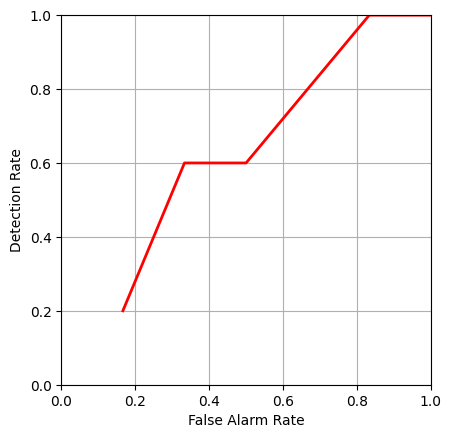

In [19]:
example_targetvals = np.array([0  ,0  ,1  ,0  ,1  ,0  ,0  ,1  ,1  ,0  ,1  ])
example_confidence = np.array([.01,.03,.10,.15,.30,.40,.45,.65,.80,.90,.95])
area_roc(example_confidence, example_targetvals, do_plot=True);